In [1]:
!pip install mediapipe

In [2]:
!pip install opencv-python-headless scikit-learn scikit-image \
             matplotlib numpy Pillow mediapipe torch torchvision \
             scipy imutils

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from google.colab import files
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from skimage.filters import prewitt, roberts, sobel
from skimage.color import rgb2gray, rgb2hsv
from skimage import img_as_float
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

print("✅  All libraries imported successfully.")

✅  All libraries imported successfully.


Saving sample_photo.jpg to sample_photo (1).jpg
Image shape: (465, 600, 3)  (H=465, W=600)


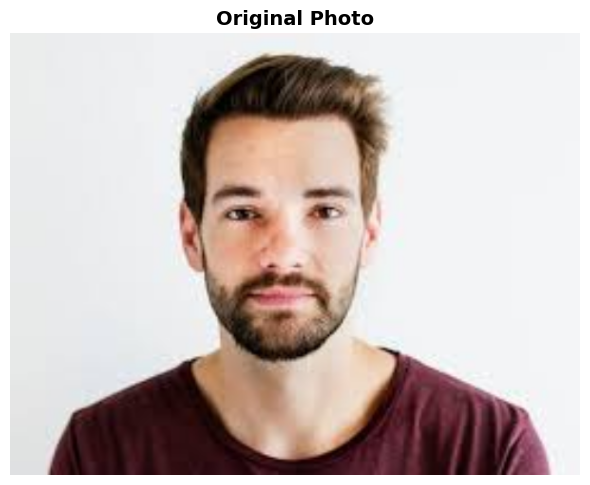

✅  Image loaded and displayed.


In [4]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Load with OpenCV (BGR) and also as PIL
img_bgr  = cv2.imread(filename)
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Resize to a manageable size while keeping aspect ratio
MAX_DIM = 600
h, w = img_rgb.shape[:2]
scale = MAX_DIM / max(h, w)
img_rgb   = cv2.resize(img_rgb,   (int(w * scale), int(h * scale)))
img_bgr   = cv2.resize(img_bgr,   (int(w * scale), int(h * scale)))
img_gray  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_float = img_as_float(img_gray)

print(f"Image shape: {img_rgb.shape}  (H={img_rgb.shape[0]}, W={img_rgb.shape[1]})")

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Original Photo", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("00_original.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅  Image loaded and displayed.")

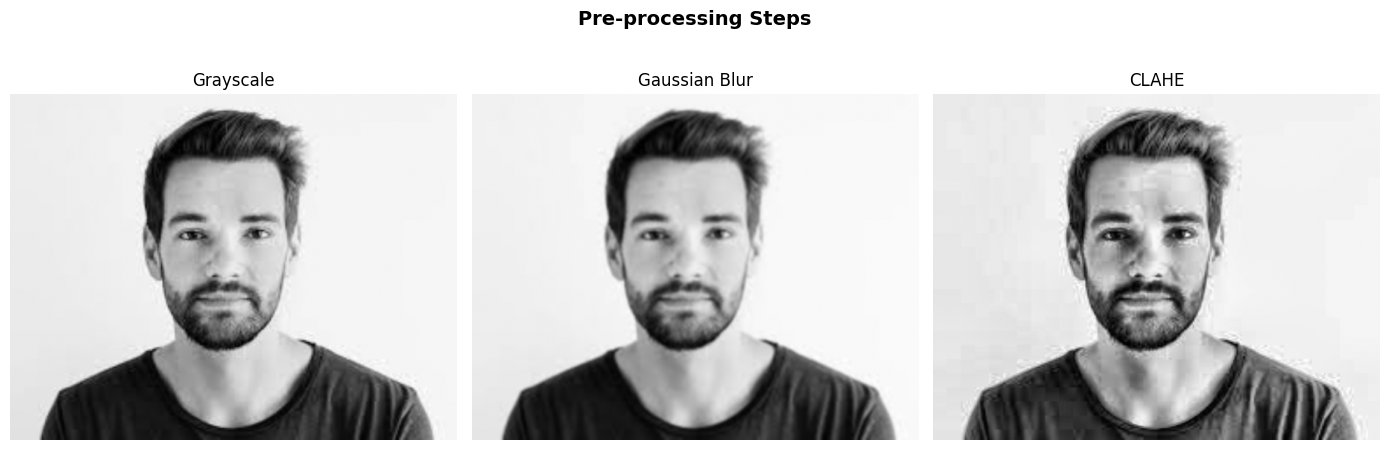

✅  Pre-processing complete.


In [5]:
img_blurred = cv2.GaussianBlur(img_gray, (5, 5), 1.4)

# CLAHE (Contrast Limited Adaptive Histogram Equalisation)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_gray)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(img_gray,    cmap='gray'); axes[0].set_title("Grayscale");     axes[0].axis('off')
axes[1].imshow(img_blurred, cmap='gray'); axes[1].set_title("Gaussian Blur"); axes[1].axis('off')
axes[2].imshow(img_clahe,   cmap='gray'); axes[2].set_title("CLAHE");         axes[2].axis('off')
plt.suptitle("Pre-processing Steps", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("01_preprocessing.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅  Pre-processing complete.")

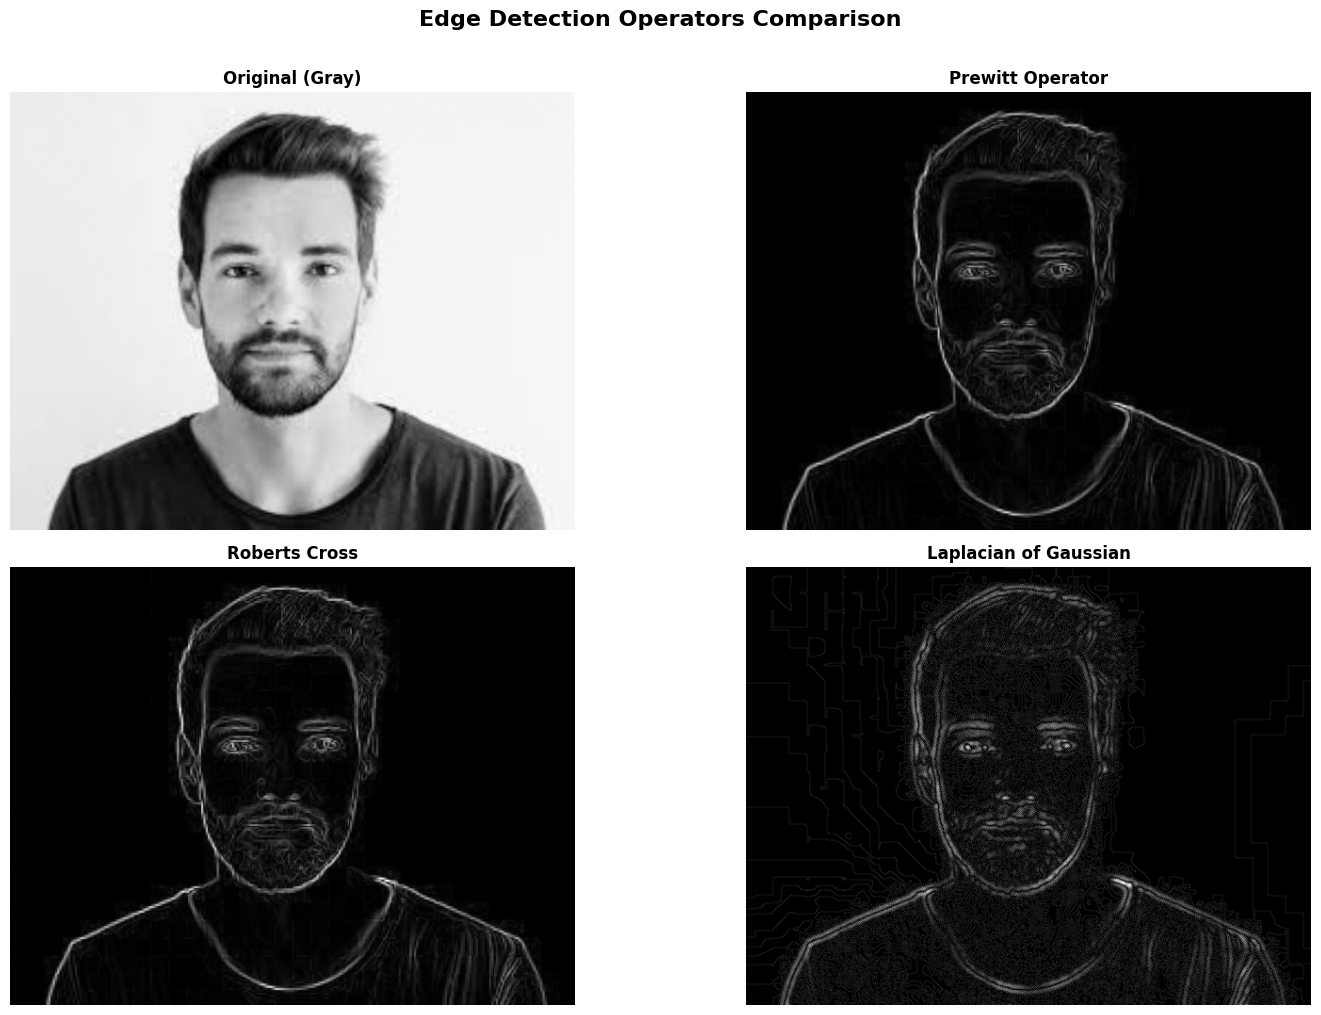

✅  Edge detection complete: Prewitt, Roberts, LoG.


In [6]:
# 5.2  Prewitt Operator (via skimage)
prewitt_edges = prewitt(img_float)
prewitt_edges = (prewitt_edges / prewitt_edges.max() * 255).astype(np.uint8)

# 5.3  Roberts Cross Operator (via skimage)
roberts_edges = roberts(img_float)
roberts_edges = (roberts_edges / roberts_edges.max() * 255).astype(np.uint8)

# 5.4  Laplacian of Gaussian (LoG)
log_blur  = gaussian_filter(img_float, sigma=2.0)
log_edges = cv2.Laplacian(np.uint8(log_blur * 255), cv2.CV_64F)
log_edges = np.abs(log_edges)
log_edges = np.uint8(log_edges / log_edges.max() * 255)

# ---- Display ----
fig, axes = plt.subplots(2,2, figsize=(16, 10))
images_edges = [
    (img_gray,     "Original (Gray)",       'gray'),
    (prewitt_edges,"Prewitt Operator",       'gray'),
    (roberts_edges,"Roberts Cross",          'gray'),
    (log_edges,    "Laplacian of Gaussian",  'gray'),
]
for ax, (img, title, cmap) in zip(axes.flat, images_edges):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Edge Detection Operators Comparison", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("02_edge_detection.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅  Edge detection complete: Prewitt, Roberts, LoG.")

✅  Face detected at x=158, y=81, w=266, h=266


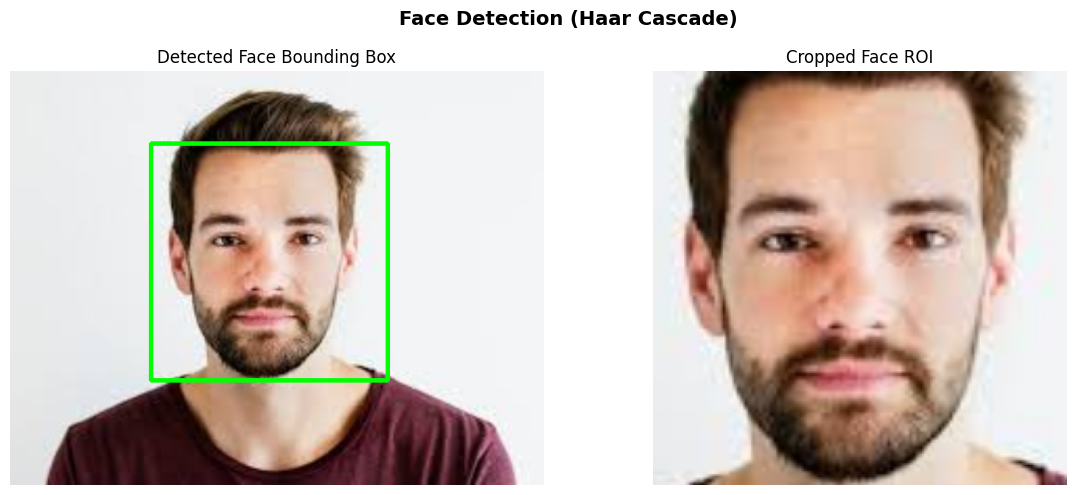

✅  Face ROI extracted.


In [7]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

faces = face_cascade.detectMultiScale(
    img_clahe, scaleFactor=1.1, minNeighbors=5, minSize=(80, 80))

if len(faces) == 0:
    print("⚠️  Auto-detection failed. Using full image as face region.")
    h_img, w_img = img_rgb.shape[:2]
    margin = 10
    x, y, fw, fh = margin, margin, w_img - 2*margin, h_img - 2*margin
else:
    # Take the largest detected face
    x, y, fw, fh = sorted(faces, key=lambda b: b[2]*b[3], reverse=True)[0]
    print(f"✅  Face detected at x={x}, y={y}, w={fw}, h={fh}")

# Draw bounding box
img_face_box = img_rgb.copy()
cv2.rectangle(img_face_box, (x, y), (x+fw, y+fh), (0, 255, 0), 3)

# Crop face ROI
face_roi_rgb  = img_rgb[y:y+fh, x:x+fw]
face_roi_gray = img_gray[y:y+fh, x:x+fw]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_face_box);   axes[0].set_title("Detected Face Bounding Box"); axes[0].axis('off')
axes[1].imshow(face_roi_rgb);   axes[1].set_title("Cropped Face ROI");           axes[1].axis('off')
plt.suptitle("Face Detection (Haar Cascade)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("03_face_detection.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅  Face ROI extracted.")

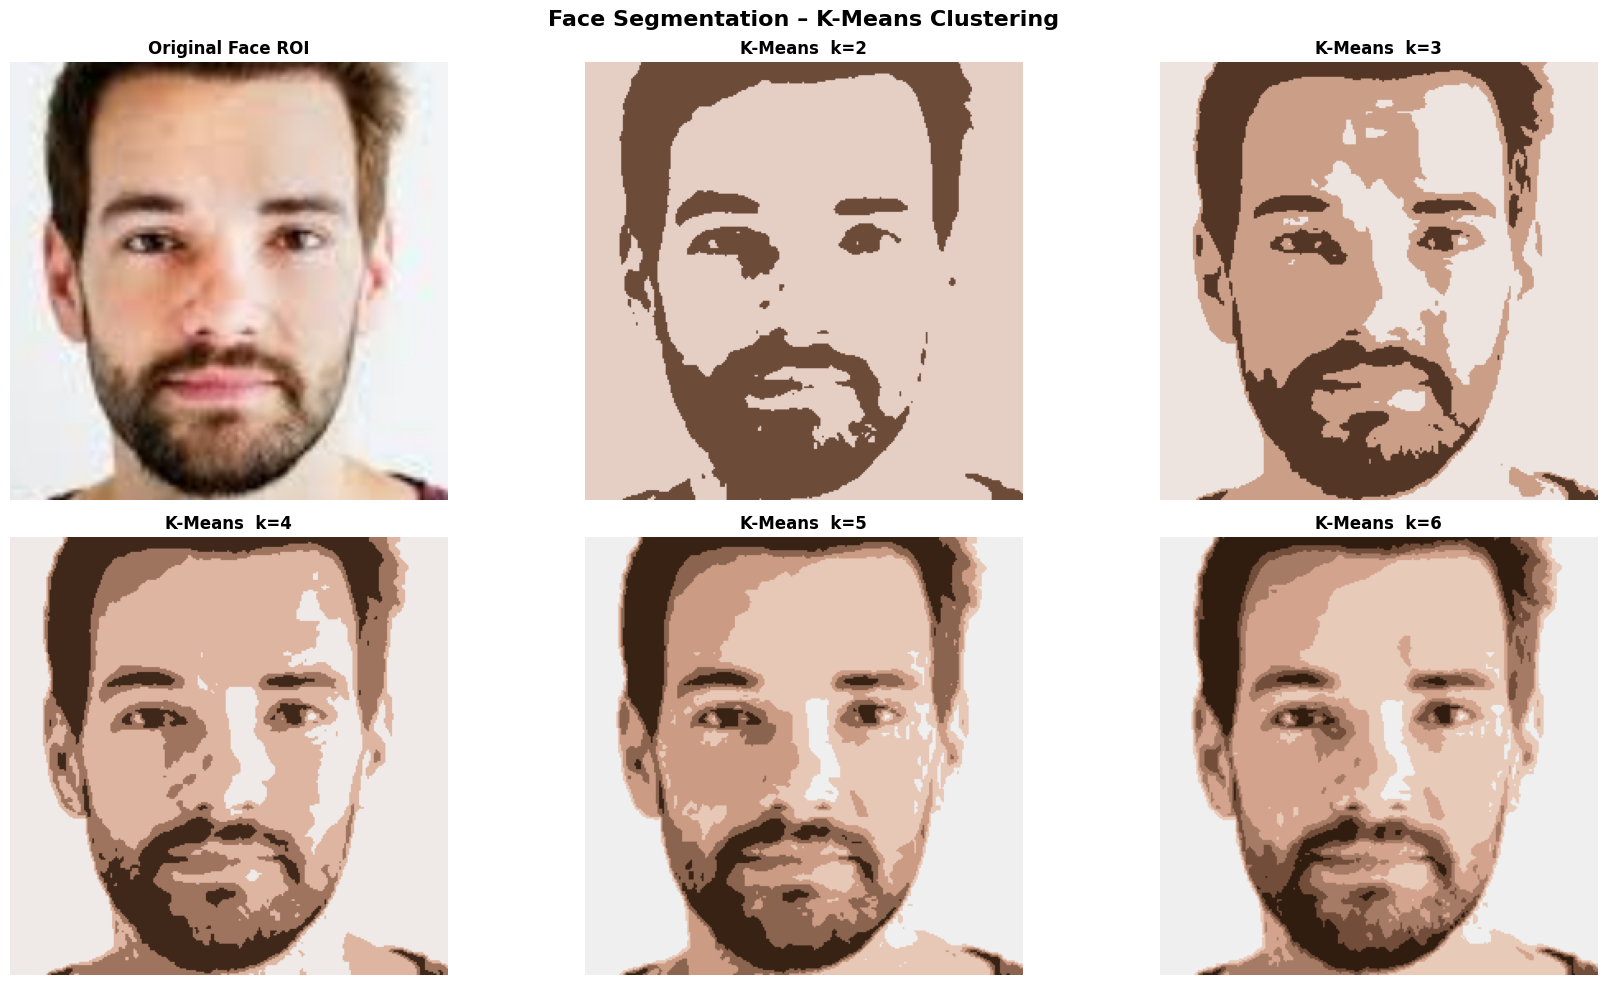

✅  K-Means segmentation complete.


In [8]:
def kmeans_segment(image_rgb, n_clusters=4):
    """Segment image using K-Means pixel clustering in RGB space."""
    h, w = image_rgb.shape[:2]
    pixels = image_rgb.reshape(-1, 3).astype(np.float32)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels, centers = cv2.kmeans(
        pixels, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    centers = np.uint8(centers)
    segmented = centers[labels.flatten()].reshape(h, w, 3)
    return segmented, labels.reshape(h, w), centers

# Run K-Means with k=2,3,4,5
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0, 0].imshow(face_roi_rgb)
axes[0, 0].set_title("Original Face ROI", fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

for idx, k in enumerate([2, 3, 4, 5, 6]):
    seg_img, labels_map, centers = kmeans_segment(face_roi_rgb, n_clusters=k)
    ax = axes.flat[idx + 1]
    ax.imshow(seg_img)
    ax.set_title(f"K-Means  k={k}", fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("Face Segmentation – K-Means Clustering", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("04_kmeans_segmentation.png", dpi=150, bbox_inches='tight')
plt.show()

# Best result (k=3 typically separates skin / hair / background well)
seg_best, labels_best, centers_best = kmeans_segment(face_roi_rgb, n_clusters=3)
print("✅  K-Means segmentation complete.")

Building training dataset...
Training SVM (RBF kernel) – this may take ~30 seconds...

SVM Classification Report:
              precision    recall  f1-score   support

    Non-skin       1.00      1.00      1.00       600
        Skin       1.00      1.00      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200

Applying SVM to full image (may take a minute)...


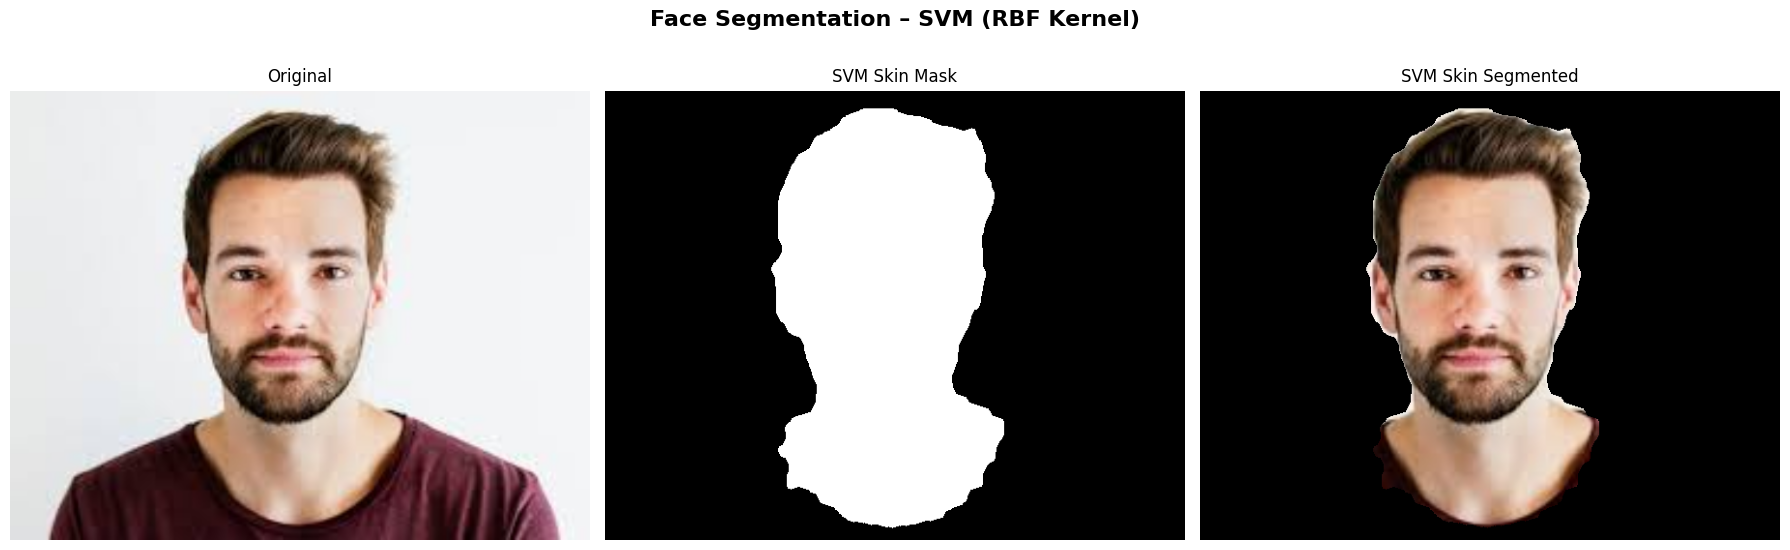

✅  SVM segmentation complete.


In [9]:
def build_skin_dataset(face_roi_rgb, full_img_rgb):
    """Create pseudo-labelled skin / non-skin samples."""
    h, w = face_roi_rgb.shape[:2]
    # Skin samples: inner 40% of face ROI
    pad_h, pad_w = int(h * 0.3), int(w * 0.3)
    skin_region   = face_roi_rgb[pad_h:h-pad_h, pad_w:w-pad_w]
    skin_pixels   = skin_region.reshape(-1, 3).astype(np.float32)

    # Non-skin samples: corners of the full image
    corner = 80
    img_h, img_w = full_img_rgb.shape[:2]
    non_skin = np.vstack([
        full_img_rgb[:corner, :corner].reshape(-1, 3),
        full_img_rgb[:corner, img_w-corner:].reshape(-1, 3),
        full_img_rgb[img_h-corner:, :corner].reshape(-1, 3),
        full_img_rgb[img_h-corner:, img_w-corner:].reshape(-1, 3),
    ]).astype(np.float32)

    # Sub-sample to keep dataset balanced and fast
    np.random.seed(42)
    n = min(len(skin_pixels), len(non_skin), 3000)
    skin_idx     = np.random.choice(len(skin_pixels), n, replace=False)
    non_skin_idx = np.random.choice(len(non_skin),    n, replace=False)

    X = np.vstack([skin_pixels[skin_idx], non_skin[non_skin_idx]])
    y = np.array([1]*n + [0]*n)
    return X, y


def rgb_to_ycbcr_features(pixels_rgb):
    """Convert Nx3 RGB array to YCbCr features."""
    img_tmp = pixels_rgb.reshape(1, -1, 3).astype(np.uint8)
    ycbcr   = cv2.cvtColor(img_tmp, cv2.COLOR_RGB2YCrCb)
    return ycbcr.reshape(-1, 3).astype(np.float32)


print("Building training dataset...")
X_raw, y = build_skin_dataset(face_roi_rgb, img_rgb)
X        = rgb_to_ycbcr_features(X_raw)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training SVM (RBF kernel) – this may take ~30 seconds...")
svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=10, gamma='scale', probability=True))

svm_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = svm_pipeline.predict(X_test)
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-skin', 'Skin']))

# Apply to full image
print("Applying SVM to full image (may take a minute)...")
h_full, w_full = img_rgb.shape[:2]
all_pixels_rgb  = img_rgb.reshape(-1, 3)
all_pixels_ycbcr = rgb_to_ycbcr_features(all_pixels_rgb)

# Predict in chunks to avoid memory issues
chunk = 10000
pred_labels = np.zeros(len(all_pixels_ycbcr), dtype=np.uint8)
for i in range(0, len(all_pixels_ycbcr), chunk):
    pred_labels[i:i+chunk] = svm_pipeline.predict(all_pixels_ycbcr[i:i+chunk])

svm_mask = pred_labels.reshape(h_full, w_full)

# Morphological clean-up
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
svm_mask_clean = cv2.morphologyEx(
    svm_mask.astype(np.uint8), cv2.MORPH_CLOSE, kernel, iterations=3)
svm_mask_clean = cv2.morphologyEx(
    svm_mask_clean, cv2.MORPH_OPEN, kernel, iterations=1)

# Overlay
svm_overlay = img_rgb.copy()
svm_overlay[svm_mask_clean == 0] = [0, 0, 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb);                    axes[0].set_title("Original");            axes[0].axis('off')
axes[1].imshow(svm_mask_clean, cmap='gray');axes[1].set_title("SVM Skin Mask");       axes[1].axis('off')
axes[2].imshow(svm_overlay);                axes[2].set_title("SVM Skin Segmented");  axes[2].axis('off')
plt.suptitle("Face Segmentation – SVM (RBF Kernel)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("05_svm_segmentation.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅  SVM segmentation complete.")

Running DeepLabV3 inference...
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:01<00:00, 136MB/s]


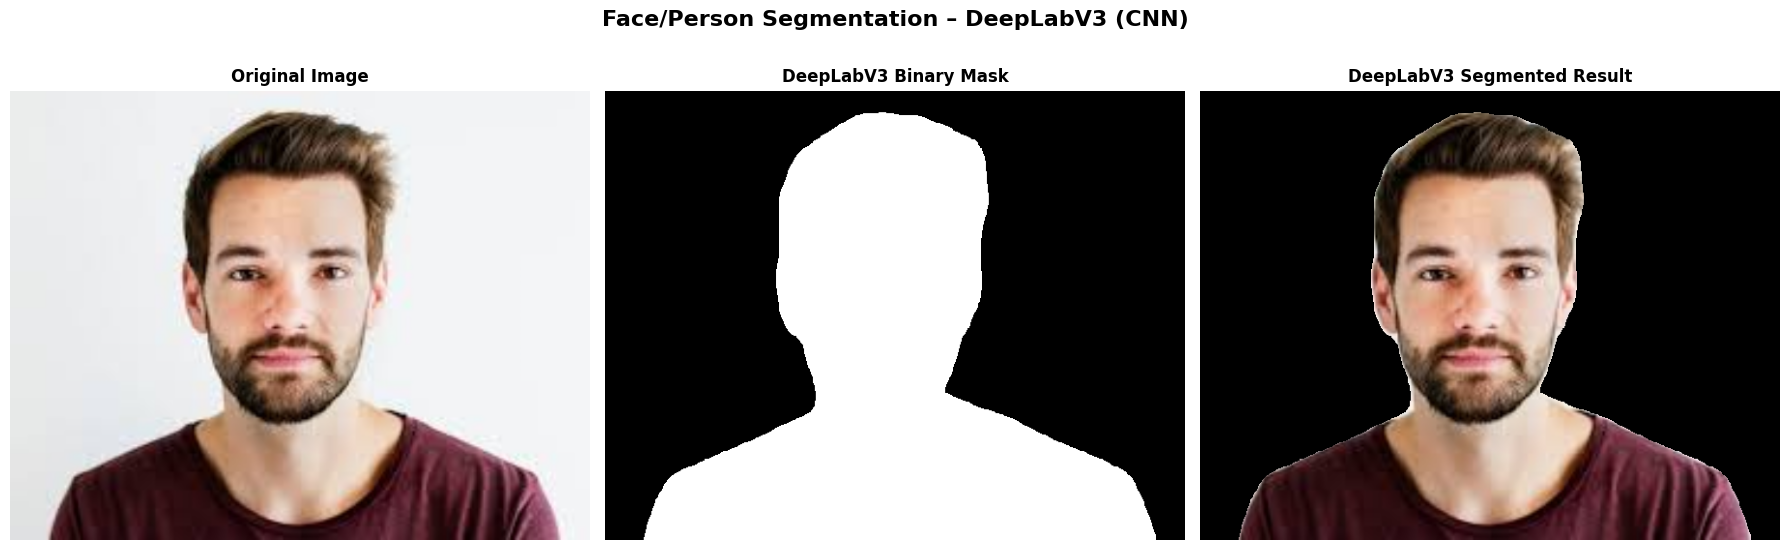

✅  DeepLabV3 segmentation complete.


In [11]:
# ──────────────────────────────────────────────────────────────
# CELL 9 (ALT) – Segmentation Method 3: Deep Learning (DeepLabV3)
# ──────────────────────────────────────────────────────────────
import torch
from torchvision import models, transforms

def get_deeplab_segmentation(image_rgb):
    # 1. Load pre-trained DeepLabV3 model (ResNet-50 backbone)
    # weights=models.segmentation.DeepLabV3_ResNet50_Weights.DEFAULT is the modern PyTorch API
    model = models.segmentation.deeplabv3_resnet50(pretrained=True).eval()

    # 2. Pre-process the image for the model
    preprocess = transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize(520),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    input_tensor = preprocess(image_rgb).unsqueeze(0)

    # 3. Inference (disable gradient calculation for speed)
    if torch.cuda.is_available():
        model = model.to('cuda')
        input_tensor = input_tensor.to('cuda')

    with torch.no_grad():
        output = model(input_tensor)['out'][0]

    # 4. Extract the 'Person' class (Index 15 in COCO dataset)
    # output.argmax(0) gives the class with highest probability for each pixel
    seg_map = output.argmax(0).cpu().numpy()

    # Create a binary mask where class == 15 (person)
    dl_mask = (seg_map == 15).astype(np.uint8) * 255

    # 5. Resize mask back to original image size
    dl_mask = cv2.resize(dl_mask, (image_rgb.shape[1], image_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 6. Apply mask to image
    dl_segmented = cv2.bitwise_and(image_rgb, image_rgb, mask=dl_mask)

    return dl_segmented, dl_mask

# Execute the segmentation
print("Running DeepLabV3 inference...")
dl_segmented_alt, dl_mask_alt = get_deeplab_segmentation(img_rgb)

# ---- Visualise Results ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original Image", fontweight='bold')
axes[0].axis('off')

axes[1].imshow(dl_mask_alt, cmap='gray')
axes[1].set_title("DeepLabV3 Binary Mask", fontweight='bold')
axes[1].axis('off')

axes[2].imshow(dl_segmented_alt)
axes[2].set_title("DeepLabV3 Segmented Result", fontweight='bold')
axes[2].axis('off')

plt.suptitle("Face/Person Segmentation – DeepLabV3 (CNN)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("06_deeplab_segmentation.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅  DeepLabV3 segmentation complete.")